### Create the data

In [33]:
import random
import torch
from torch import nn, optim
import math
from IPython import display

In [34]:
from res.plot_lib import plot_data, plot_model, set_default

In [35]:
set_default()

In [36]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [37]:
seed = 12345
random.seed(seed)
torch.manual_seed(seed)
N = 1000  # num_samples_per_class
D = 2  # dimensions
C = 3  # num_classes
H = 100  # num_hidden_units

In [38]:
X = torch.zeros(N * C, D).to(device)
y = torch.zeros(N * C, dtype=torch.long).to(device)
for c in range(C):
   index = 0
   t = torch.linspace(0, 1, N)
   # When c = 0 and t = 0: start of linspace
   # When c = 0 and t = 1: end of linpace
   # This inner_var is for the formula inside sin() and cos() like sin(inner_var) and cos(inner_Var)
   inner_var = torch.linspace(
     # When t = 0
     (2 * math.pi / C) * (c),
     # When t = 1
     (2 * math.pi / C) * (2 + c),
     N
   ) + torch.randn(N) * 0.2
   
   for ix in range(N * c, N * (c + 1)):
     X[ix] = t[index] * torch.FloatTensor((
       math.sin(inner_var[index]), math.cos(inner_var[index])
     ))
     y[ix] = c
     index += 1

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (3000, 2)
y: (3000,)


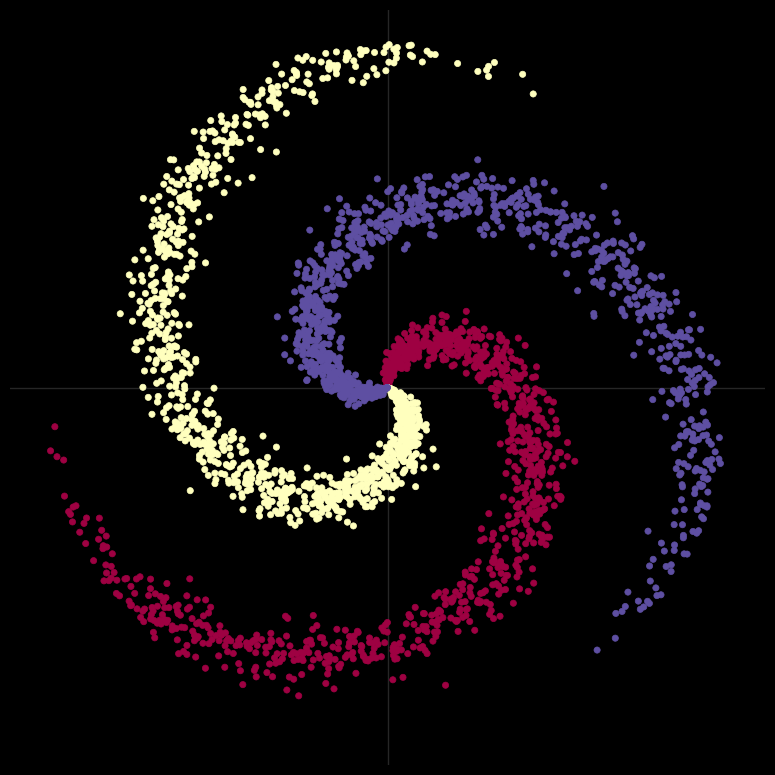

In [39]:
# visualise the data
plot_data(X, y)

### Linear model

In [40]:
learning_rate = 1e-3
lambda_l2 = 1e-5

In [41]:
# nn package to create our linear model
# each Linear module has a weight and bias
model = nn.Sequential(
   nn.Linear(D, H),
   nn.Linear(H, C)
)
model.to(device) #Convert to CUDA

# nn package also has different loss functions.
# we use cross entropy loss for our classification task
#criterion = nn.CrossEntropyLoss()

# we use the optim package to apply
# stochastic gradient descent for our parameter updates
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

# Training
for t in range(1000):
   
   # Feed forward to get the logits
   y_pred = model(X)
   
   # Compute the loss and accuracy
   loss = nn.CrossEntropyLoss(y_pred, y)
   score, predicted = torch.max(y_pred, 1)
   acc = (y == predicted).sum().float() / len(y)
   print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
   display.clear_output(wait=True)
   
   # zero the gradients before running
   # the backward pass.
   optimizer.zero_grad()
   
   # Backward pass to compute the gradient
   # of loss w.r.t our learnable params. 
   loss.backward()
   
   # Update params
   optimizer.step()

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [ ]:
len(list(model.parameters()))

4

In [ ]:
# Plot trained model
print(model)
plot_model(X, y, model)

### Two-layered network

In [ ]:
learning_rate = 1e-3
lambda_l2 = 1e-5

In [69]:
   # nn package to create our linear model
   # each Linear module has a weight and bias
   # 
def train(activation,  hidden_dim, epochs=1000):

    model = nn.Sequential(
        nn.Linear(D, hidden_dim),
        activation,
        nn.Linear(hidden_dim, C)
    )
    model.to(device)

    
    # we use the optim package to apply
    # ADAM for our parameter updates
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_l2) # built-in L2

    # e = 1.  # plotting purpose

    # Training
    for t in range(epochs):
        
        # Feed forward to get the logits
        y_pred = model(X)
        
        # Compute the loss and accuracy
        # nn package also has different loss functions.
        # we use cross entropy loss for our classification task

        loss = torch.nn.CrossEntropyLoss(y_pred, y)
        score, predicted = torch.max(y_pred, 1)   # returns (max_value, index)
        acc = (y == predicted).sum().float() / len(y)
        
        display.clear_output(wait=True)
        print("[EPOCH]: %i, [LOSS]: %.6f, [ACCURACY]: %.3f" % (t, loss.item(), acc))
        
        # zero the gradients before running
        # the backward pass.
        optimizer.zero_grad()
        
        # Backward pass to compute the gradient
        # of loss w.r.t our learnable params. 
        loss.backward()
        
        # Update params
        optimizer.step()
    # Plot trained model
    #print(model)
    plot_model(X, y, model)


[EPOCH]: 999, [LOSS]: 0.168757, [ACCURACY]: 0.955


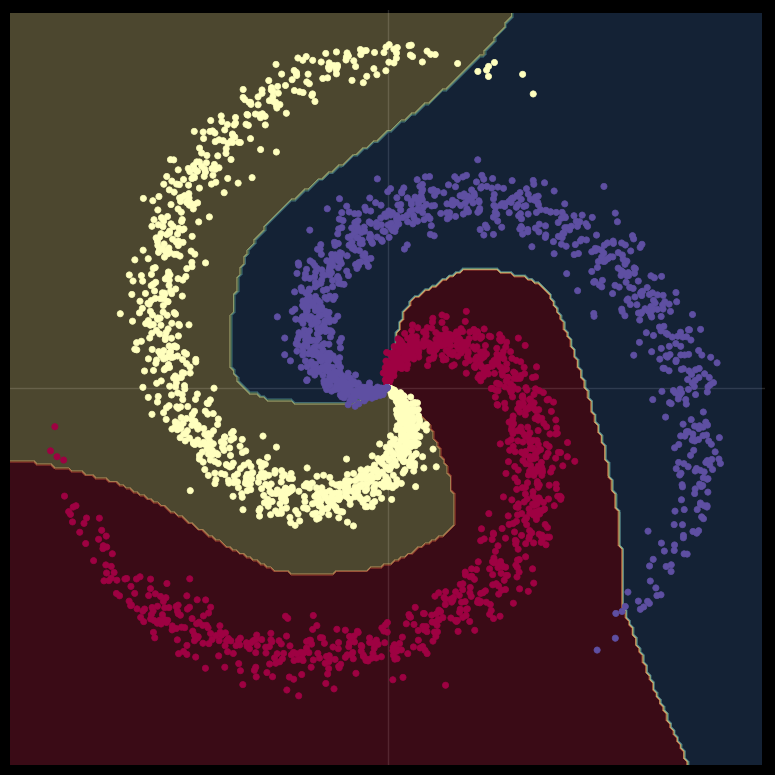

In [70]:
train(nn.ReLU(), 100)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=3, bias=True)
)


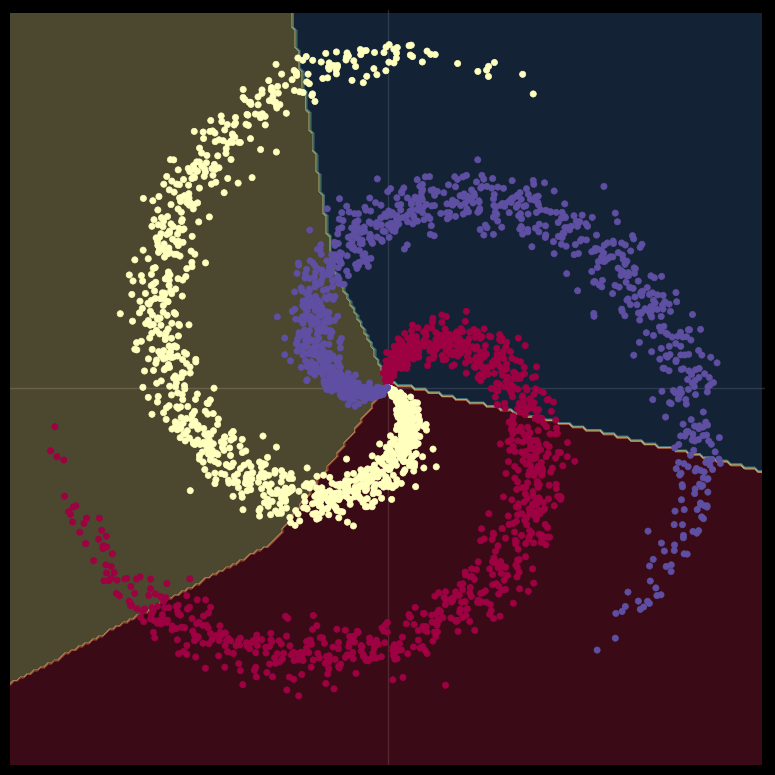

In [60]:
train(nn.ReLU(), 5)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=3, bias=True)
)


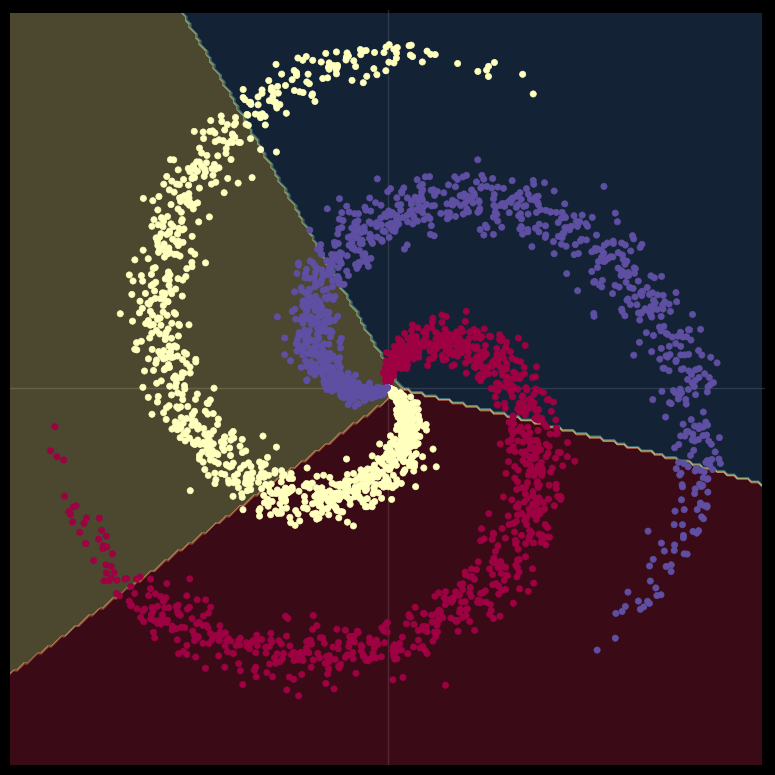

In [61]:
train(nn.Sigmoid(), 5)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=3, bias=True)
)


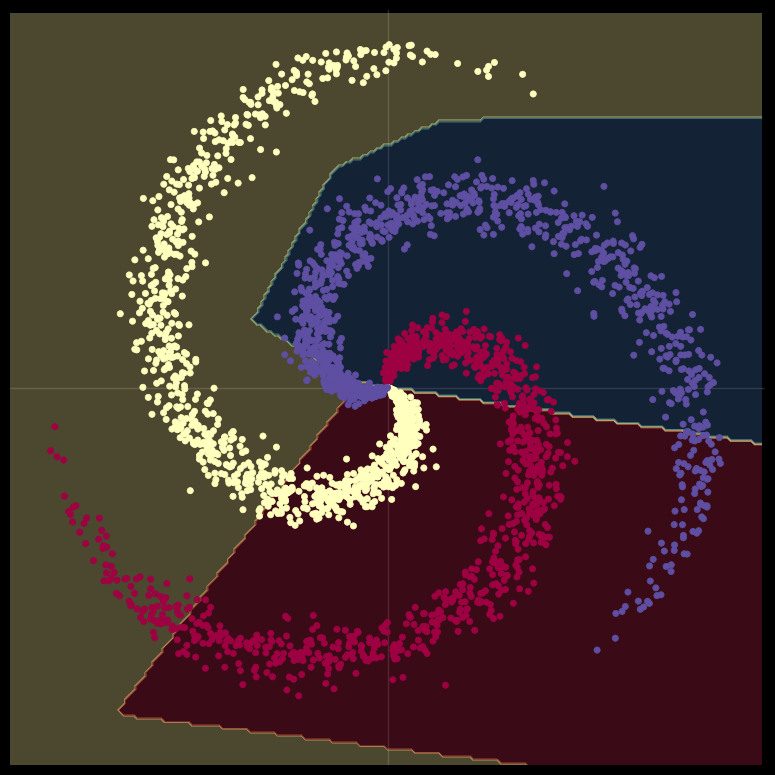

In [63]:
train(nn.ReLU(), 5, epochs=10000)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=3, bias=True)
)


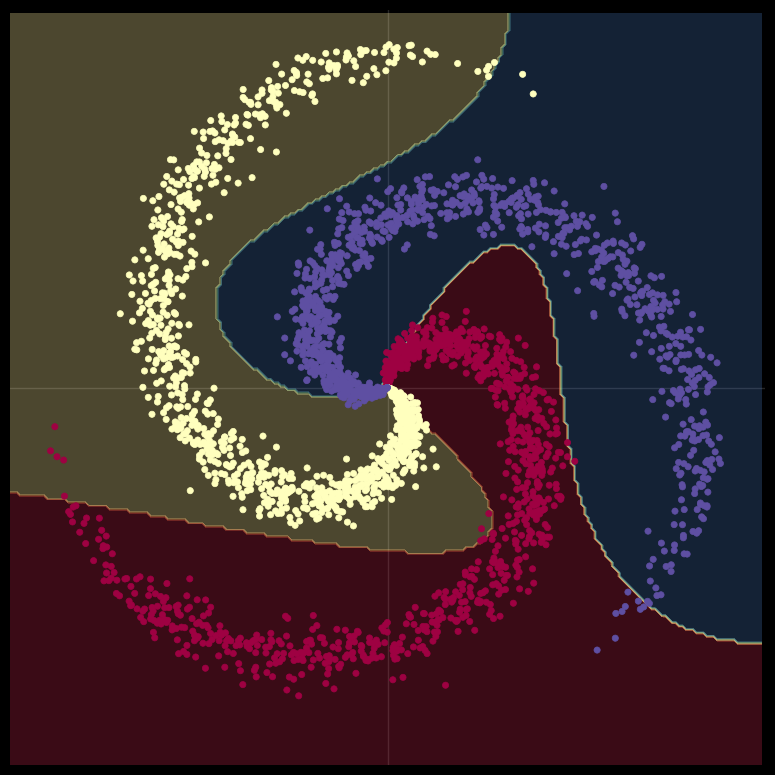

In [64]:
train(nn.Sigmoid(), 5, epochs=10000)

Sequential(
  (0): Linear(in_features=2, out_features=1000, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1000, out_features=3, bias=True)
)


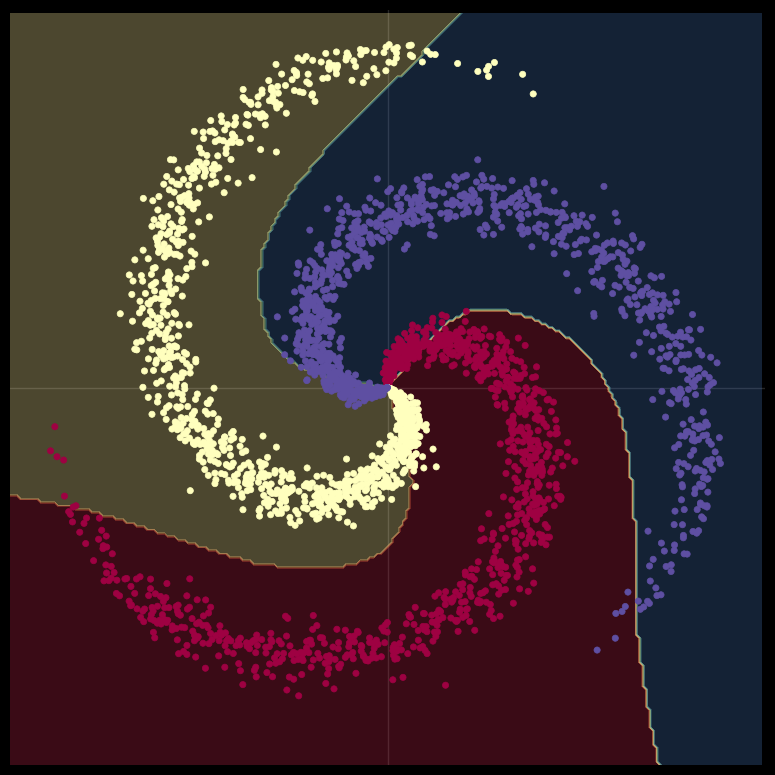

In [65]:
train(nn.ReLU(), 1000, epochs=100)

Sequential(
  (0): Linear(in_features=2, out_features=1000, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=1000, out_features=3, bias=True)
)


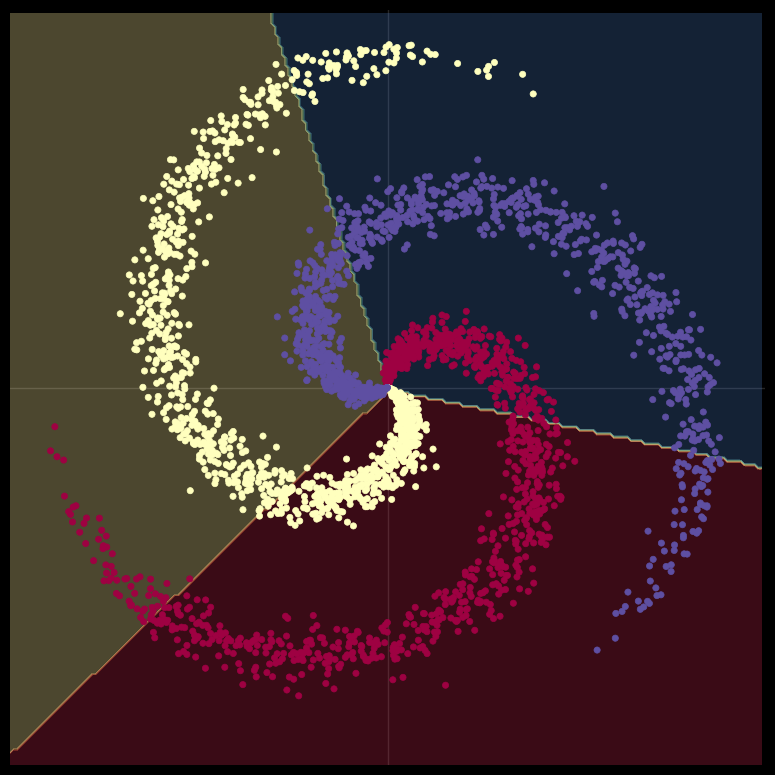

In [66]:
train(nn.Sigmoid(), 1000, epochs=100)

## Homework: define a neural network with 6 layers of dimension 2 and use it to classify the points on the spiral.

## Homework: Use a computer algebra software to compute and visualize the cost function for a neural network for the spiral classification problem, with a single hidden layer of dimension 3. Do this bor both ReLU and sigmoid activations.  